In [1]:
from pathlib import Path
from dataclasses import dataclass
import random
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as T

import timm
import torchmetrics
from torchinfo import summary
from thop import profile
print("numpy : ",np.__version__)
print("sklearn : ",sklearn.__version__)
print("torch : ",torch.__version__)
print("torchmetrics : ",torchmetrics.__version__)
print("torchvision : ",torchvision.__version__)


g:\4th_Sem\EL_1\Anaconda\envs\polyps\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


numpy :  2.2.6
sklearn :  1.7.2
torch :  2.7.1+cu118
torchmetrics :  1.9.0
torchvision :  0.22.1+cu118


In [2]:
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
from pathlib import Path
from dataclasses import dataclass

NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parents[1]

CLASSIFY_DIR = (BASE_DIR / "data" / "raw" / "Kvasir-classify")
DATASET_DIR = (CLASSIFY_DIR / "kvasir-dataset")
SPLIT_DIR = (CLASSIFY_DIR/ "kvasir-dataset-split")

TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR = SPLIT_DIR / "val"

MODEL_OUTPUT_DIR = (BASE_DIR/ "models"/ NOTEBOOK_DIR.name)

MODEL_OUTPUT_DIR.mkdir(parents=True,exist_ok=True)


@dataclass
class Config:
    img_size: int = 224
    batch_size: int = 16
    num_workers: int = 0
    epochs: int = 25
    lr: float = 1e-4
    weight_decay: float = 1e-4
    num_classes: int = 8
    model_name: str = "efficientnet_b0"
    device: str = ("cuda" if torch.cuda.is_available() else "cpu")


cfg = Config()

In [4]:
class GIEndoscopyDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx] # ('~/kvasir-dataset/dyed-lifted-polyps/b4ad64a8098a.jpg',0)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [5]:
from torchvision.datasets import ImageFolder
from pprint import pprint

train_folder = ImageFolder(TRAIN_DIR)
val_folder = ImageFolder(VAL_DIR)

class_names = train_folder.classes

print("Classes")
pprint(class_names)

print("\nClass Mapping")
pprint(train_folder.class_to_idx)

train_samples = train_folder.samples
val_samples = val_folder.samples

print(f"\nTrain Images: {len(train_samples)}")
print(f"Validation Images: {len(val_samples)}")

Classes
['dyed-lifted-polyps',
 'dyed-resection-margins',
 'esophagitis',
 'normal-cecum',
 'normal-pylorus',
 'normal-z-line',
 'polyps',
 'ulcerative-colitis']

Class Mapping
{'dyed-lifted-polyps': 0,
 'dyed-resection-margins': 1,
 'esophagitis': 2,
 'normal-cecum': 3,
 'normal-pylorus': 4,
 'normal-z-line': 5,
 'polyps': 6,
 'ulcerative-colitis': 7}

Train Images: 2801
Validation Images: 1201


In [6]:
train_tfms = T.Compose(
    [
        T.Resize((cfg.img_size, cfg.img_size)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=10),
        T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
        T.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.95, 1.05)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
val_tfms = T.Compose(
    [
        T.Resize((cfg.img_size, cfg.img_size)),
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [7]:
train_ds = GIEndoscopyDataset(train_samples, train_tfms)
val_ds = GIEndoscopyDataset(val_samples, val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
)

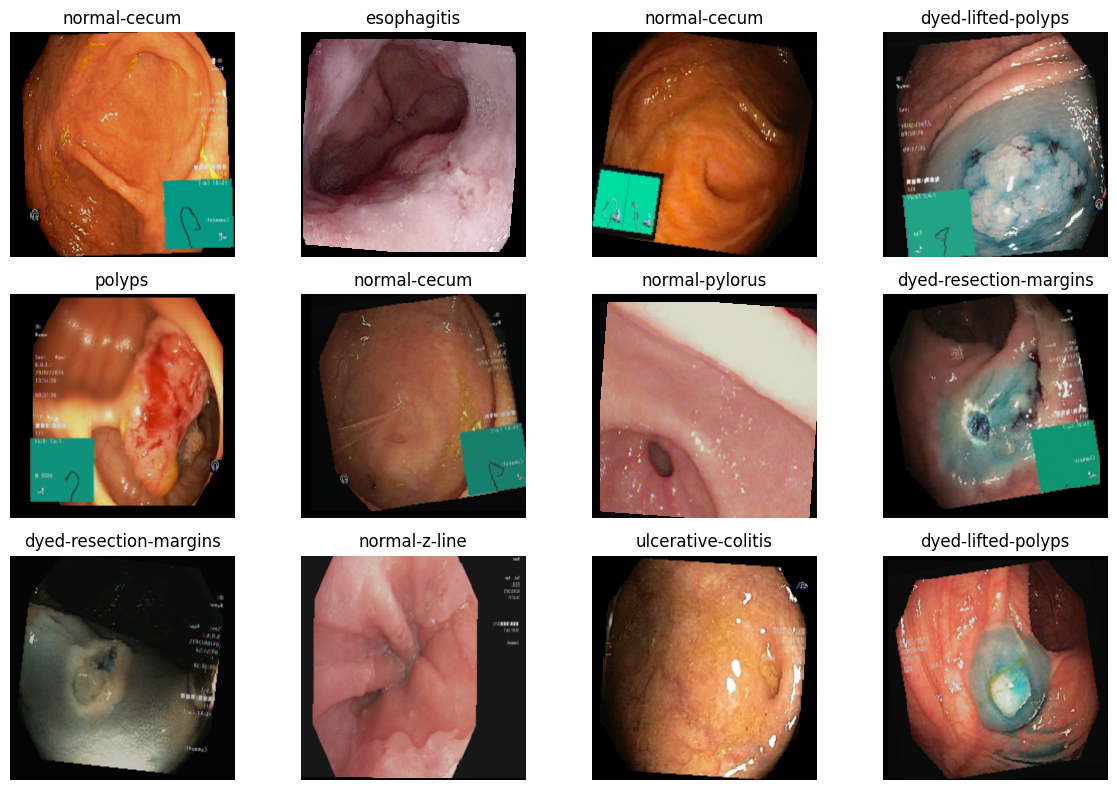

In [8]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for ax, img, label in zip(axes.flatten(), images[:12], labels[:12]):
    img = img.permute(1, 2, 0).numpy()
    # undo normalization
    img = img * std + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[label.item()])
    ax.axis("off")

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / "train_img_samaples.png", dpi=150, bbox_inches='tight')
# plt.show()

In [9]:
model = timm.create_model(
    cfg.model_name, pretrained=True, num_classes=cfg.num_classes
).to(cfg.device)

g:\4th_Sem\EL_1\Anaconda\envs\polyps\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Zaid\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [10]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
param_size_mb = total_params * 4 / (1024**2)  # float32
dummy = torch.randn(1, 3, cfg.img_size,cfg.img_size).to(cfg.device)
macs, params = profile(model, inputs=(dummy,), verbose=False)

print(f"MACs:   {macs / 1e9:.3f} G")
print(f"Params: {params / 1e6:.3f} M")
print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Frozen Parameters:    {frozen_params:,}")
print(f"Approx model size: {param_size_mb:.2f} MB")
summary(
    model,
    input_size=(1, 3, 224, 224),
    col_names=["input_size", "output_size", "num_params", "mult_adds"],
)

MACs:   0.385 G
Params: 3.976 M
Total Parameters:     4,017,796
Trainable Parameters: 4,017,796
Frozen Parameters:    0
Approx model size: 15.33 MB


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Mult-Adds
EfficientNet                                  [1, 3, 224, 224]          [1, 8]                    --                        --
├─Conv2d: 1-1                                 [1, 3, 224, 224]          [1, 32, 112, 112]         864                       10,838,016
├─BatchNormAct2d: 1-2                         [1, 32, 112, 112]         [1, 32, 112, 112]         64                        --
│    └─Identity: 2-1                          [1, 32, 112, 112]         [1, 32, 112, 112]         --                        --
│    └─SiLU: 2-2                              [1, 32, 112, 112]         [1, 32, 112, 112]         --                        --
├─Sequential: 1-3                             [1, 32, 112, 112]         [1, 320, 7, 7]            --                        --
│    └─Sequential: 2-3                        [1, 32, 112, 112]         [1, 16, 112, 112]       

In [11]:
targets = np.array(labels)
class_counts = np.bincount(targets)
weights = 1.0 / class_counts
weights = torch.tensor(weights, dtype=torch.float).to(cfg.device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
acc_metric = torchmetrics.Accuracy(task="multiclass", num_classes=8).to(cfg.device)
bal_acc_metric = torchmetrics.Accuracy(
    task="multiclass", num_classes=8, average="macro"
).to(cfg.device)
f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=8, average="macro").to(
    cfg.device
)
precision_metric = torchmetrics.Precision(
    task="multiclass", num_classes=8, average="macro"
).to(cfg.device)
recall_metric = torchmetrics.Recall(
    task="multiclass", num_classes=8, average="macro"
).to(cfg.device)
mcc_metric = torchmetrics.MatthewsCorrCoef(task="multiclass", num_classes=8).to(
    cfg.device
)
auroc_metric = torchmetrics.AUROC(task="multiclass", num_classes=8).to(cfg.device)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2
)

C:\Users\Zaid\AppData\Local\Temp\ipykernel_159936\365577530.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(labels)


In [12]:
best_f1 = 0
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
}

In [13]:
main_pbar = tqdm(range(cfg.epochs), desc="Total Progress", position=0)

for epoch in main_pbar:
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0
    # The inner progress bar (Training Batches)
    # leave=False removes the bar once the epoch phase is done
    train_pbar = tqdm(
        train_loader, desc=f"Epoch {epoch + 1} [Train]", position=1, leave=False
    )

    for images, targets in train_pbar:
        images, targets = (
            images.to(cfg.device, non_blocking=True),
            targets.to(cfg.device, non_blocking=True),
        )

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = running_train_loss / len(train_loader)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    acc_metric.reset()

    # The inner progress bar (Validation Batches)
    val_pbar = tqdm(
        val_loader, desc=f"Epoch {epoch + 1} [Val]", position=1, leave=False
    )

    with torch.no_grad():
        for images, targets in val_pbar:
            images, targets = images.to(cfg.device), targets.to(cfg.device)
            logits = model(images)
            loss = criterion(logits, targets)

            preds = torch.argmax(logits, dim=1)
            acc_metric.update(preds, targets)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_acc = acc_metric.compute().item()

    # --- UPDATES & LOGGING ---
    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()  # Updated after the full epoch

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(
        f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.2e}"
    )

    # Save Best Model based on Validation Accuracy (since other metrics were removed)
    if val_acc > best_f1:
        best_f1 = val_acc
        torch.save(model.state_dict(), str(MODEL_OUTPUT_DIR / "best_efficientnet_b0.pt"))
        print("Saved best model.")

Total Progress:   0%|          | 0/25 [00:00<?, ?it/s]

Train Loss: 1.0129 | Val Loss: 0.5693 | Val Acc: 0.8077 | LR: 1.00e-04


Total Progress:   4%|▍         | 1/25 [03:55<1:34:20, 235.85s/it]

Saved best model.


Train Loss: 0.4157 | Val Loss: 0.4319 | Val Acc: 0.8585 | LR: 9.76e-05


...

Train Loss: 0.0199 | Val Loss: 0.3006 | Val Acc: 0.9151 | LR: 3.45e-05
Saved best model.


Total Progress:  96%|█████████▌| 24/25 [38:21<01:29, 89.53s/it]

Train Loss: 0.0175 | Val Loss: 0.3060 | Val Acc: 0.9209 | LR: 2.73e-05
Saved best model.


Total Progress: 100%|██████████| 25/25 [39:51<00:00, 95.68s/it]

Train Loss: 0.0171 | Val Loss: 0.3216 | Val Acc: 0.9084 | LR: 2.06e-05


In [14]:
import json
from pathlib import Path

output_path = MODEL_OUTPUT_DIR / "history.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=4, ensure_ascii=False)

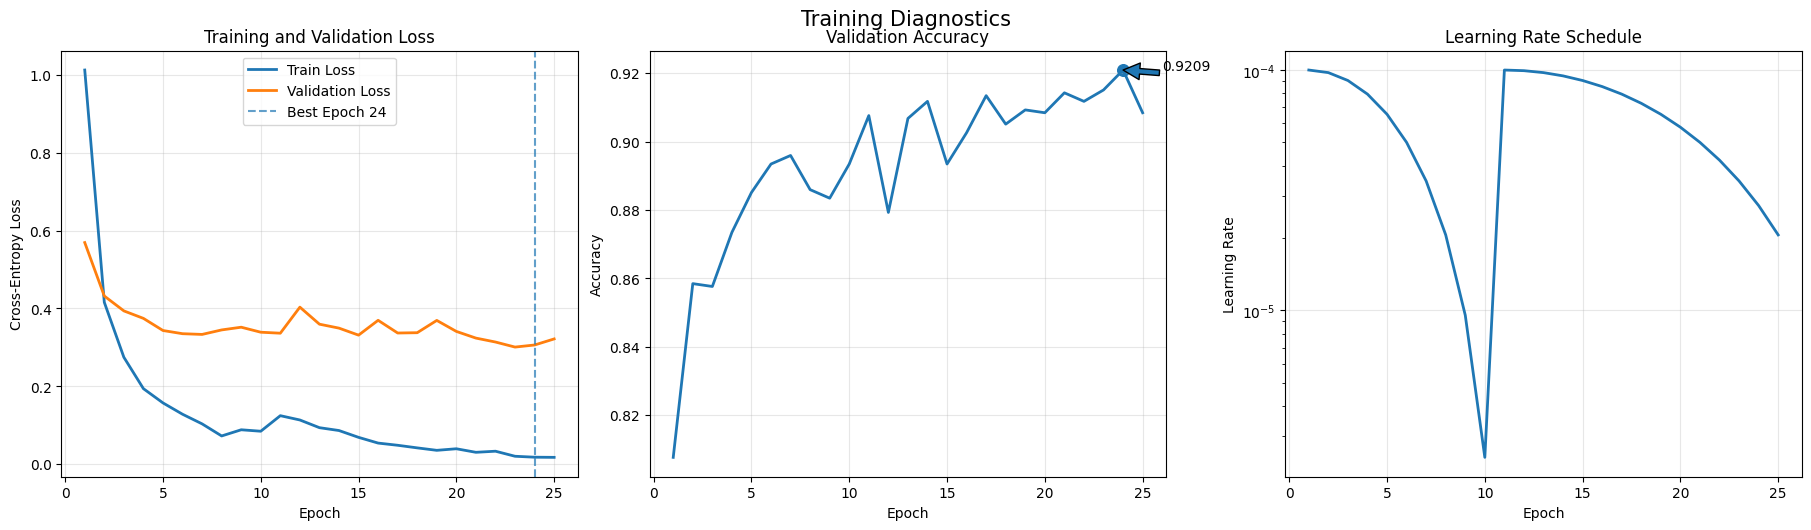

In [15]:
plt.style.use("seaborn-v0_8-darkgrid")

epochs = np.arange(1, len(history["train_loss"]) + 1)
best_epoch = np.argmax(history["val_acc"]) + 1
best_acc = np.max(history["val_acc"])

plt.style.use("default")  # or "ggplot"

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5), constrained_layout=True)

# 1. Loss Curves
axes[0].plot(epochs, history["train_loss"], linewidth=2, label="Train Loss")
axes[0].plot(epochs, history["val_loss"], linewidth=2, label="Validation Loss")
axes[0].axvline(best_epoch, linestyle="--", alpha=0.7, label=f"Best Epoch {best_epoch}")
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2. Validation Accuracy
axes[1].plot(epochs, history["val_acc"], linewidth=2)
axes[1].scatter(best_epoch, best_acc, s=70)
axes[1].annotate(
    f"{best_acc:.4f}",
    xy=(best_epoch, best_acc),
    xytext=(best_epoch + 2, best_acc),
    arrowprops=dict(),
)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

# 3. Learning Rate Schedule
axes[2].plot(epochs, history["lr"], linewidth=2)
axes[2].set_title("Learning Rate Schedule")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_yscale("log")  # important for LR plots
axes[2].grid(alpha=0.3)

fig.suptitle("Training Diagnostics", fontsize=15, y=1.03)
plt.savefig(MODEL_OUTPUT_DIR / "training_stats.png", dpi=150, bbox_inches='tight')
# plt.show()

In [16]:
model.load_state_dict(
    torch.load(str(MODEL_OUTPUT_DIR / "best_efficientnet_b0.pt"), map_location=cfg.device)
)

model.eval()

all_preds = []
all_targets = []
all_probs = []

with torch.no_grad():
    pbar = tqdm(val_loader, desc="Final Evaluation")

    for images, targets in pbar:
        images = images.to(cfg.device)
        targets = targets.to(cfg.device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.append(preds.cpu())
        all_targets.append(targets.cpu())
        all_probs.append(probs.cpu())

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()
all_probs = torch.cat(all_probs).numpy()

Final Evaluation: 100%|██████████| 76/76 [00:19<00:00,  3.90it/s]


In [17]:
from sklearn.metrics import (
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
)

acc = (all_preds == all_targets).mean()
bal_acc = balanced_accuracy_score(all_targets, all_preds)
macro_f1 = f1_score(all_targets, all_preds, average="macro")
mcc = matthews_corrcoef(all_targets, all_preds)

print("FINAL TEST METRICS")
print(f"Accuracy:          {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"MCC:               {mcc:.4f}")

FINAL TEST METRICS
Accuracy:          0.9209
Balanced Accuracy: 0.9210
Macro F1:          0.9210
MCC:               0.9098


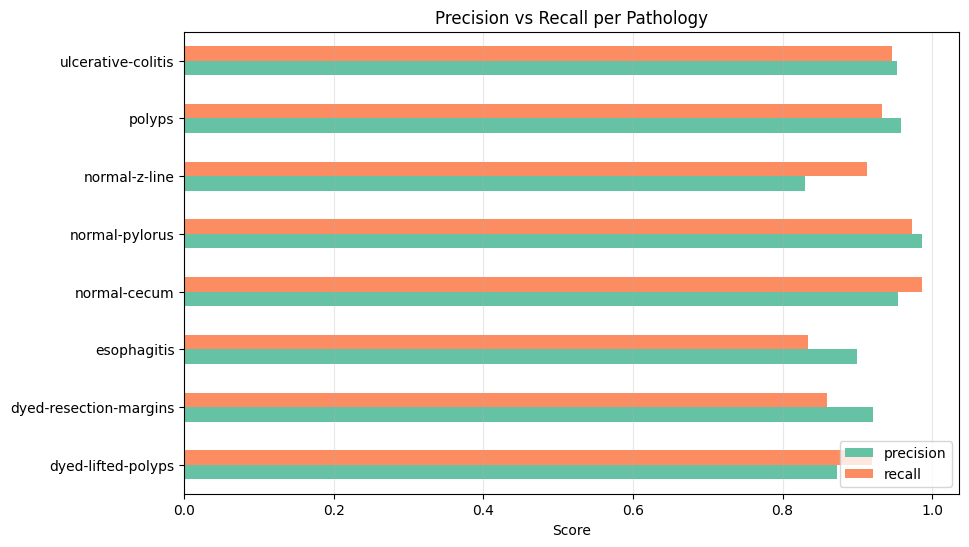

In [18]:
import pandas as pd

report = classification_report(all_targets, all_preds, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose().iloc[:-3, :] # Exclude avg/accuracy rows

fig, ax = plt.subplots(figsize=(10, 6))
df_report[['precision', 'recall']].plot(kind='barh', ax=ax, color=['#66c2a5', '#fc8d62'])
ax.set_title("Precision vs Recall per Pathology")
ax.set_xlabel("Score")
plt.grid(axis='x', alpha=0.3)
plt.savefig(MODEL_OUTPUT_DIR / "pvsr_per_class.png", dpi=150, bbox_inches='tight')
# plt.show()

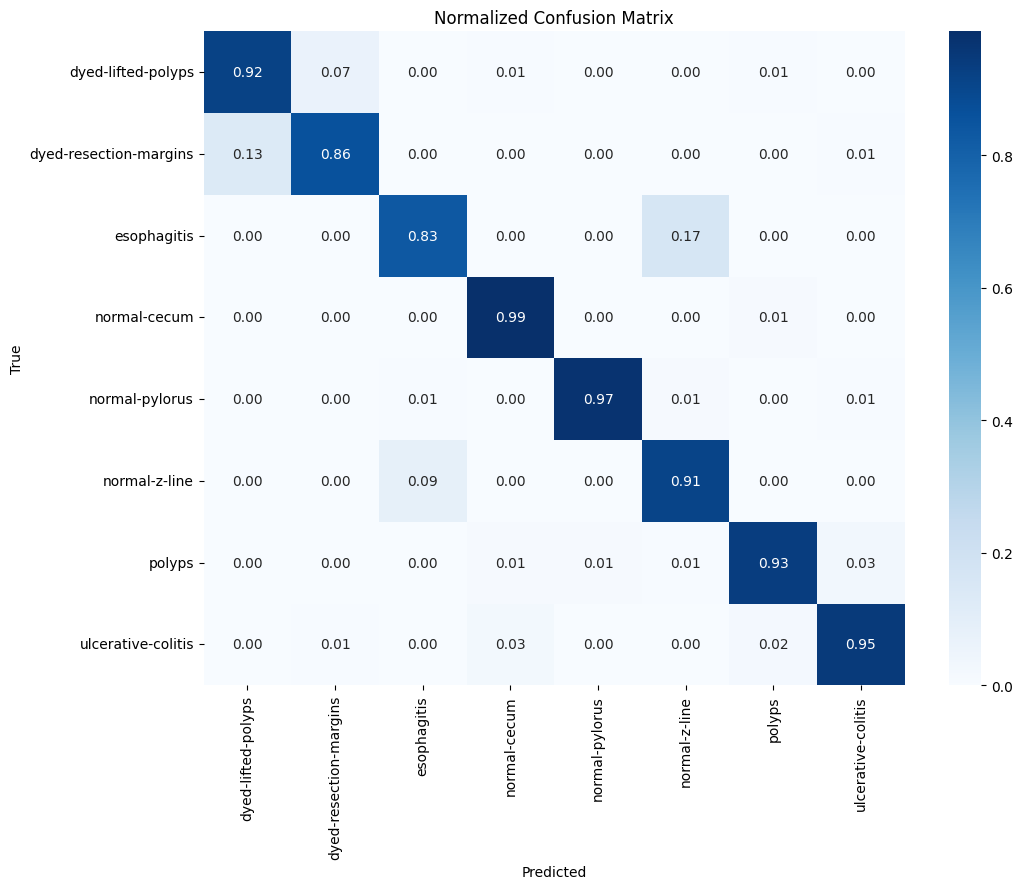

In [19]:
cm = confusion_matrix(all_targets, all_preds, normalize="true")
plt.figure(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches='tight')
# plt.show()

In [20]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(all_targets, all_probs, multi_class="ovr")
print(f"Multiclass AUROC: {auc:.4f}")

Multiclass AUROC: 0.9952


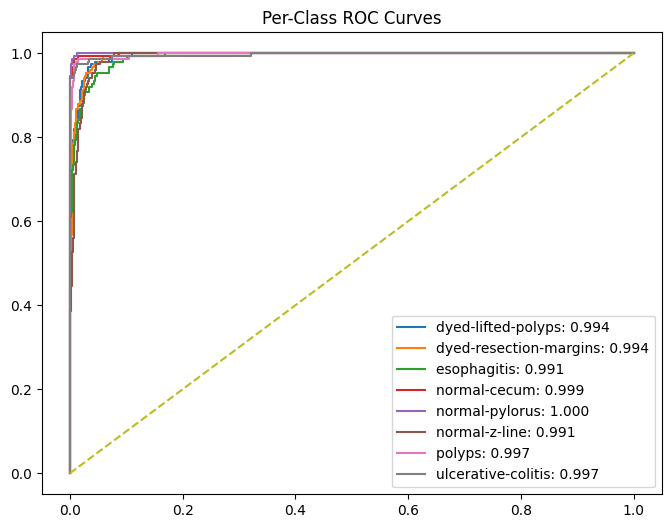

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(
    all_targets,
    classes=np.arange(len(class_names))
)

plt.figure(figsize=(8,6))

for i,name in enumerate(class_names):
    fpr,tpr,_ = roc_curve(
        y_true_bin[:,i],
        all_probs[:,i]
    )
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{name}: {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("Per-Class ROC Curves")
plt.savefig(MODEL_OUTPUT_DIR / "roc_per_class.png", dpi=150, bbox_inches='tight')
# plt.show()

Misclassified: 95


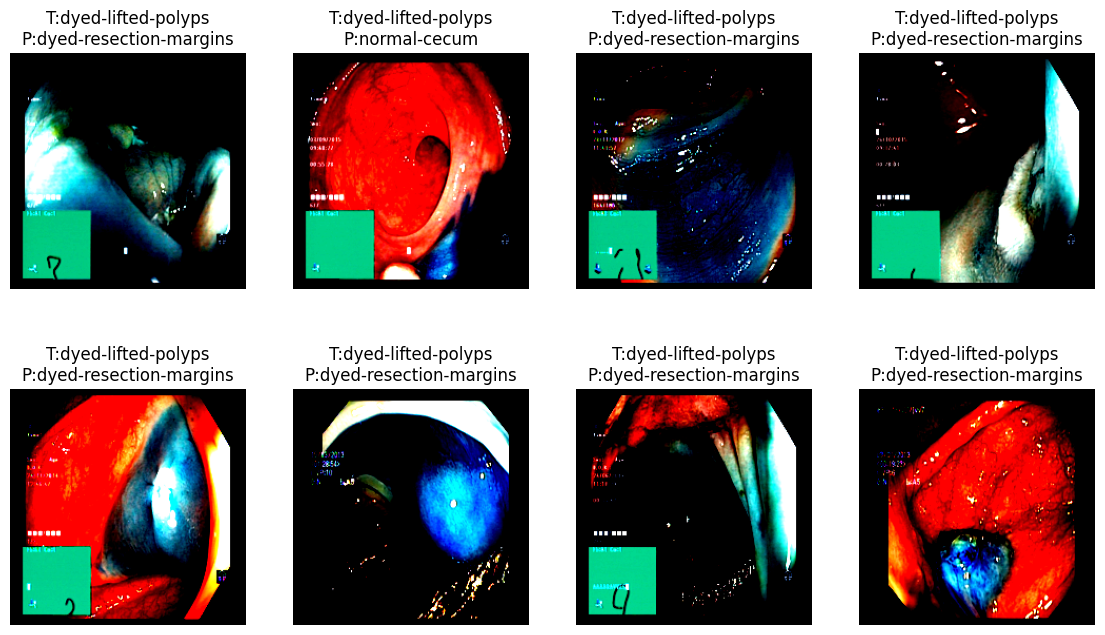

In [22]:
wrong = np.where(all_preds != all_targets)[0]
print(f"Misclassified: {len(wrong)}")
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
for ax, idx in zip(axes.flat, wrong[:8]):
    img, label = val_ds[idx]
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title(f"T:{class_names[all_targets[idx]]}\nP:{class_names[all_preds[idx]]}")
    ax.axis("off")
# plt.show()